SCRIPT FOR PLOTTING THE CORRELATION OF FEATURES OVER THE GRID MAP

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import datetime
import pandas as pd
import seaborn as sns
import geopandas as gpd
from shapely.geometry import Polygon
from matplotlib.colors import ListedColormap
import os


In [2]:
data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\\Up_Orbits-max-val-location.pkl')

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\286915373.py:1: SyntaxWarning: invalid escape sequence '\P'
  data = pd.read_pickle('C:\PROJECT-DEMETER\VAE-Image\\Up_Orbits-max-val-location.pkl')


In [3]:
cb_limit = (0.0, 1)

Creating a df with the correlation values between each features 

In [6]:


all_data = []


for specific_key in data.keys():
    all_band_values = {}

    for grid_data in data[specific_key]:
        for band_key, band_data in grid_data.items():
            if band_key.startswith('fb_'):
                if band_key in all_band_values:
                    all_band_values[band_key].append(band_data)
                else:
                    all_band_values[band_key] = [band_data]

    correlations = []


    for band_key, band_values in all_band_values.items():
        datetime_values = [entry['datetime'] for entry in band_values]
        q1_values = [entry['Q1'] for entry in band_values]
        q2_values = [entry['Q2'] for entry in band_values]
        q3_values = [entry['Q3'] for entry in band_values]
        max_values = [entry['max'] for entry in band_values]
        data_all = [{'datetime': datetime_val, 'band_key': band_key, 'Q1': q1_val, 'Q2': q2_val, 'Q3': q3_val, 'max': max_val} 
                    for datetime_val, q1_val, q2_val, q3_val, max_val in zip(datetime_values, q1_values, q2_values, q3_values, max_values)]


        df = pd.DataFrame(data_all)
        df = df[df['datetime'] <= '2010']
        df = df.drop(columns=['band_key', 'datetime'])
        corr_q1q2 = df['Q1'].corr(df['Q2'])
        corr_q2q3 = df['Q2'].corr(df['Q3'])
        corr_q1q3 = df['Q1'].corr(df['Q3'])
        corr_q1max = df['Q1'].corr(df['max'])
        corr_q2max = df['Q2'].corr(df['max'])
        corr_q3max = df['Q3'].corr(df['max'])

        correlations.append({
            'specific_key': specific_key,
            'band_key': band_key,
            'q1q2': corr_q1q2,
            'q2q3': corr_q2q3,
            'q1q3': corr_q1q3,
            'q1max': corr_q1max,
            'q2max': corr_q2max,
            'q3max': corr_q3max
        })

    corr_df = pd.DataFrame(correlations)
    all_data.append(corr_df)


df_corr = pd.concat(all_data, ignore_index=True)


folder_path = r'C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE'
os.makedirs(folder_path, exist_ok=True)
df_corr.to_csv(os.path.join(folder_path, 'Correlations_Quantiles.pkl'), index=False)



Plotting the given correlation feature over the GRID MAP

<>:68: SyntaxWarning: invalid escape sequence '\G'
<>:68: SyntaxWarning: invalid escape sequence '\G'
C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:68: SyntaxWarning: invalid escape sequence '\G'
  df_corr = pd.read_csv('C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\GRID-FB-UP_ICE\\Correlations_Quantiles.pkl')  # Replace with your actual DataFrame loading code
C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


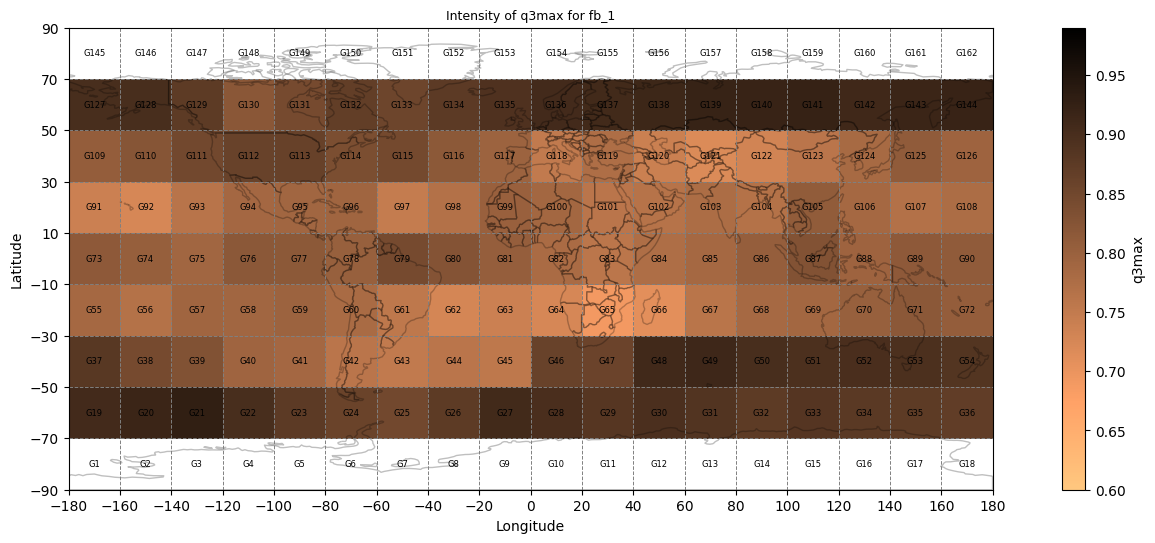

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


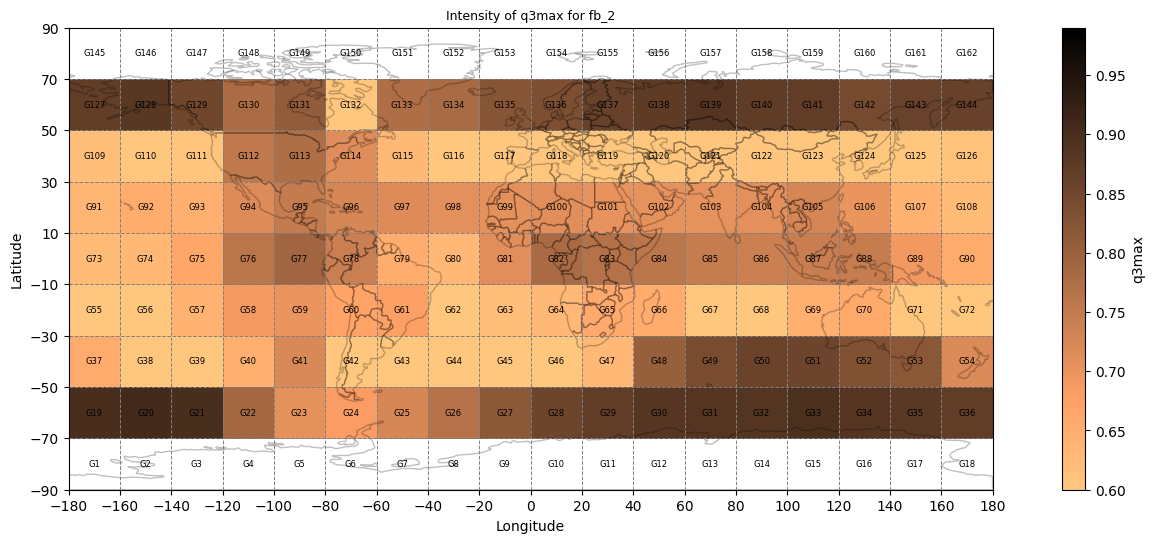

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


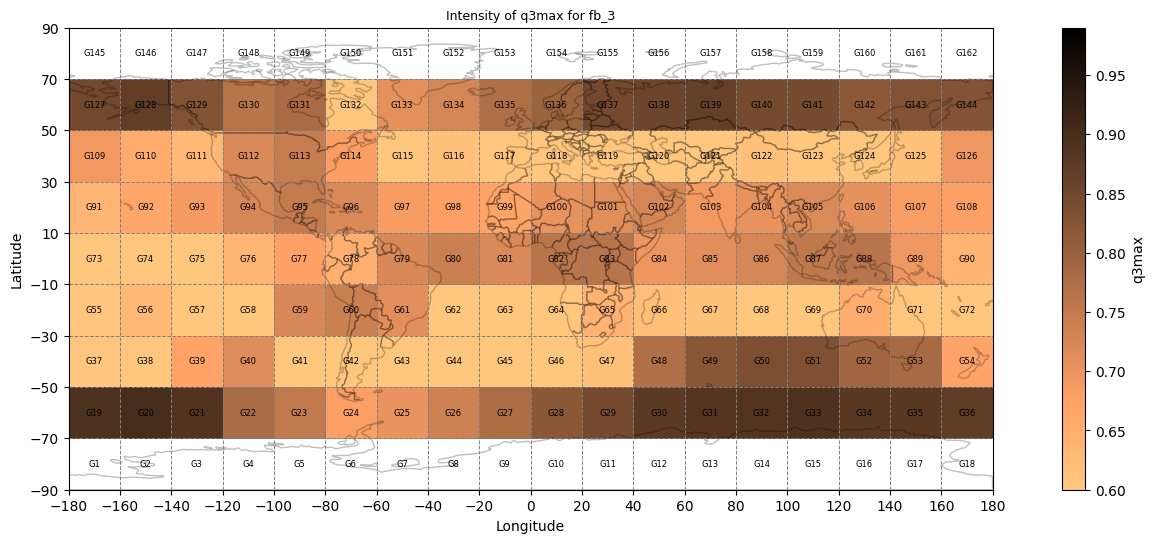

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


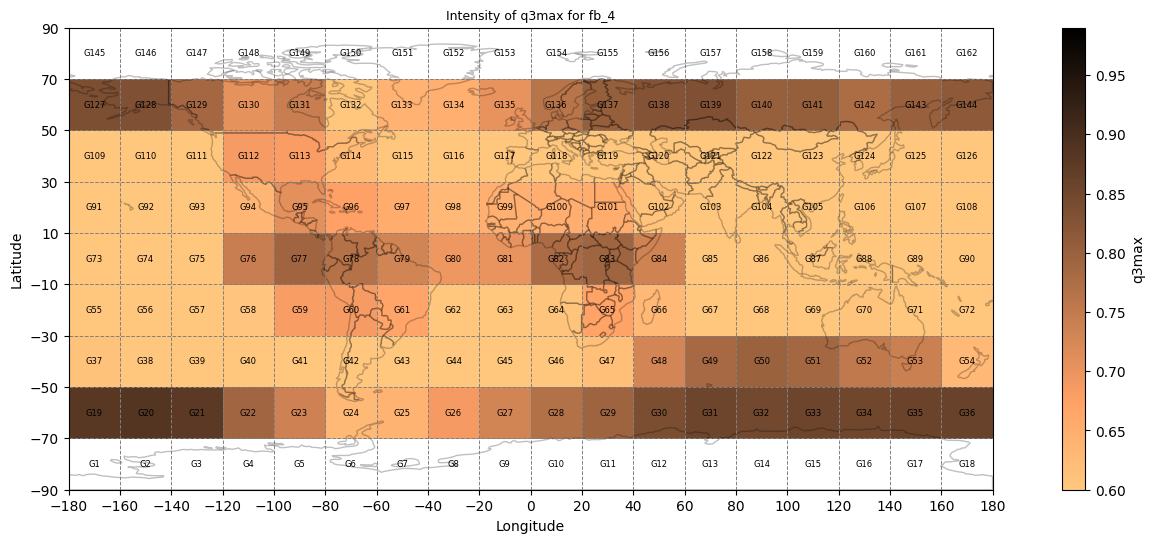

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


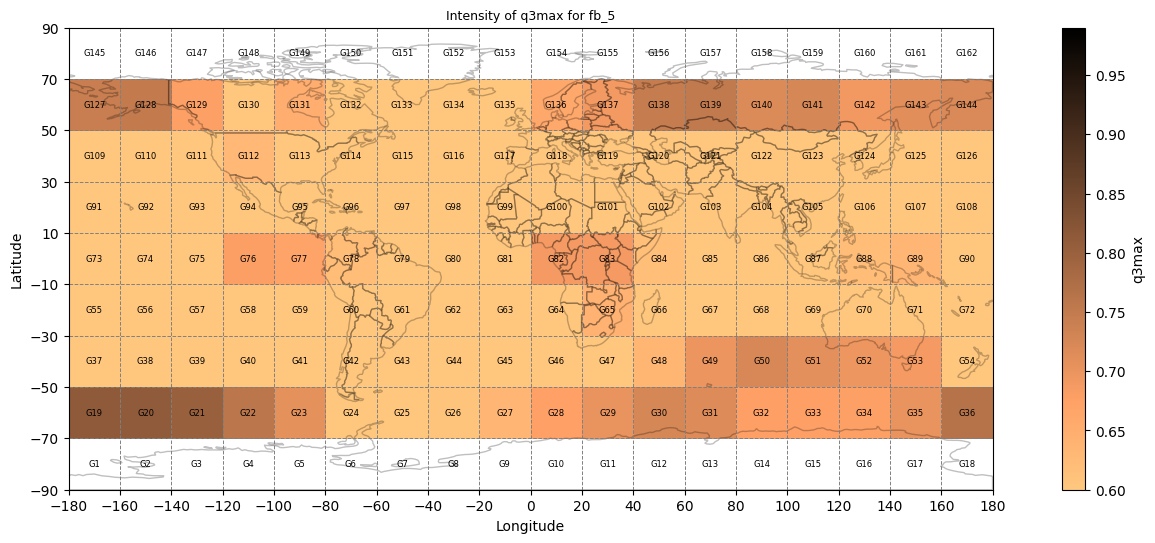

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


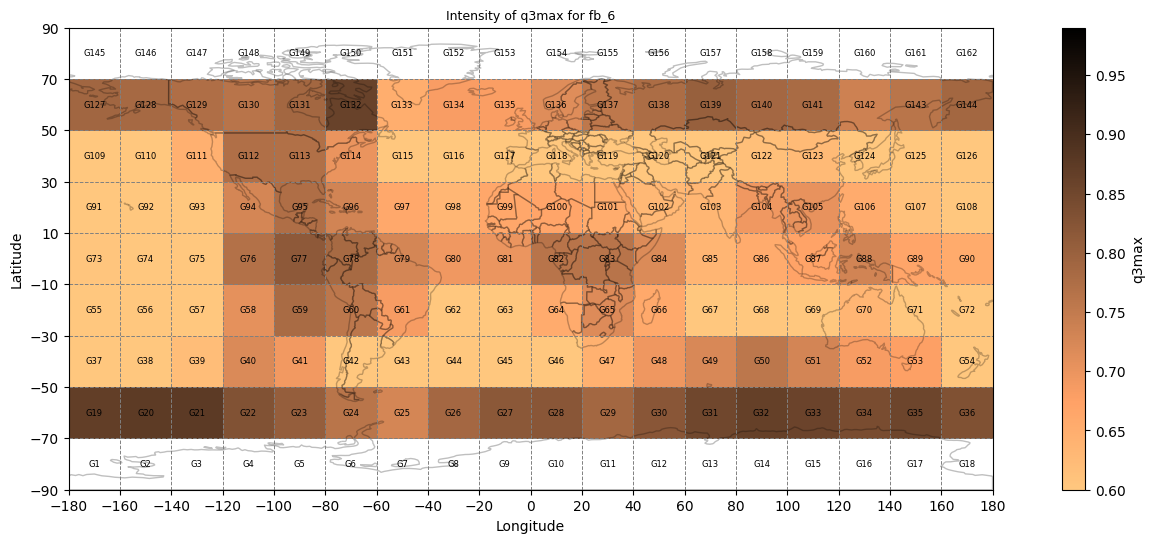

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


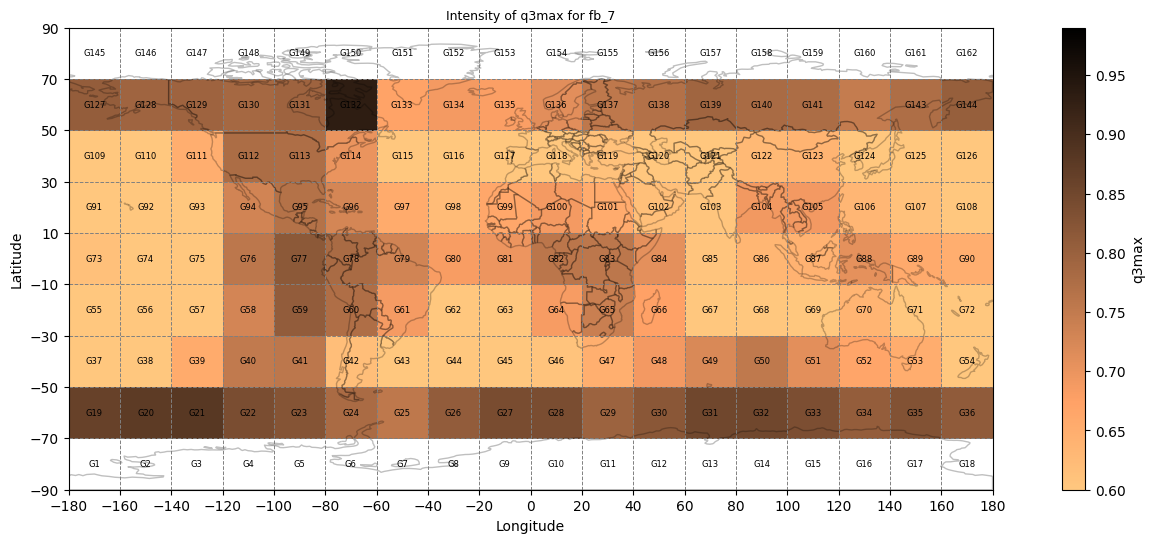

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


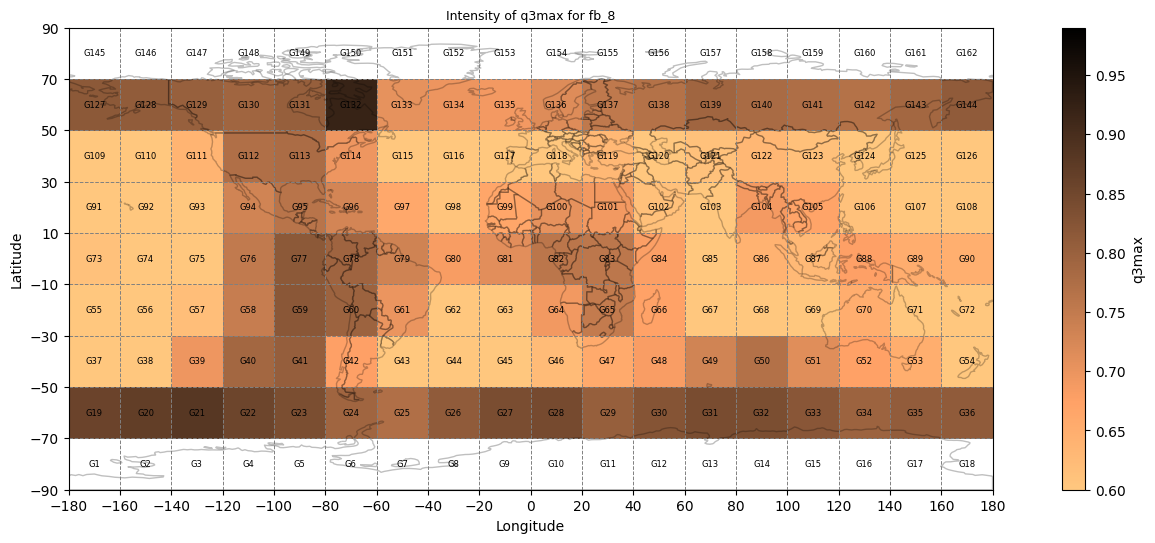

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


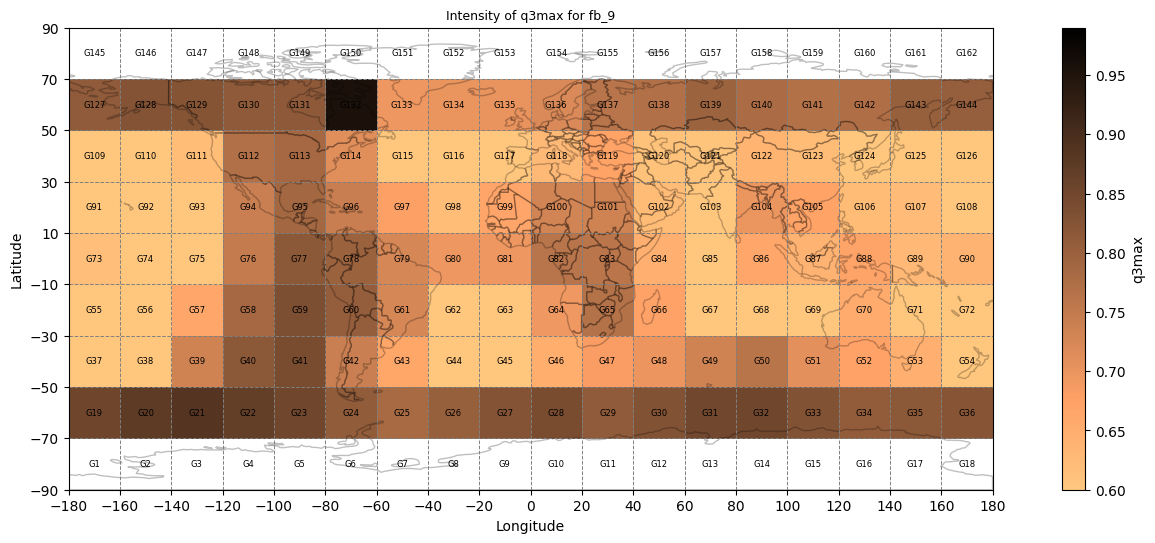

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


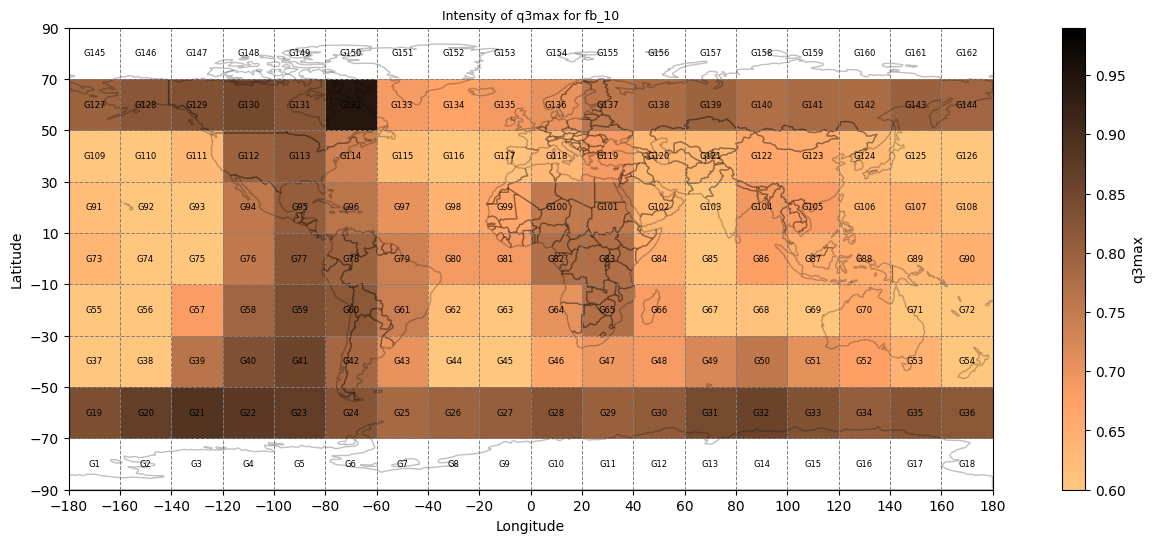

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\2362050474.py:28: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


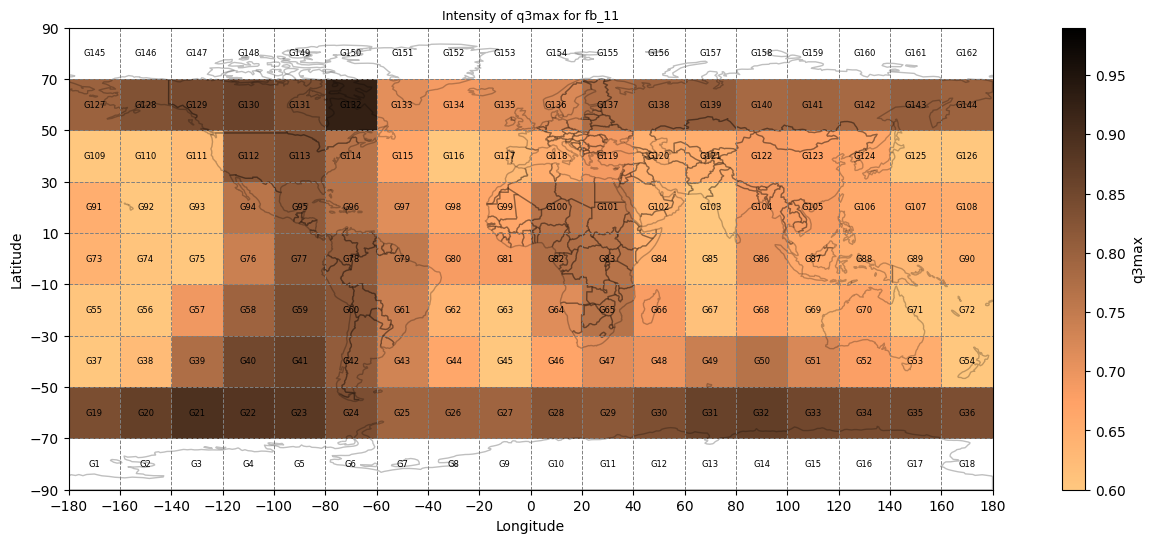

In [14]:


def create_grid(width, depth):
    min_lat, max_lat = -90, 90
    min_lon, max_lon = -180, 180
    
    num_lat_cells = int((max_lat - min_lat) / depth)
    num_lon_cells = int((max_lon - min_lon) / width)
    
    grid = np.empty((num_lat_cells, num_lon_cells), dtype=object)
    
    for lon_idx in range(num_lon_cells):
        for lat_idx in range(num_lat_cells):
            grid[lat_idx, lon_idx] = f'G{lat_idx * num_lon_cells + lon_idx + 1}'

    return grid

def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column, Band_Key):
    fig, ax = plt.subplots(figsize=(18, 6))
    # cmap = 'hot_r'
    cmap = 'copper_r'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', cmap=cmap, alpha=0.25, zorder=2)
    
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)
    for lon in np.arange(0, 361, width):
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)
    
    intensities = np.zeros(grid.shape)
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            intensity = all_data.loc[specific_key, intensity_column] if specific_key in all_data.index else np.nan
            intensities[lat_idx, lon_idx] = intensity

    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower')
    im.set_clim(vmin=0.60, vmax=.99)
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label(intensity_column)
    
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize=6)
    
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))
    
    ax.set_title(f'Intensity of {intensity_column} for {Band_Key}', fontsize=9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    
    folder_path = r"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE\\Heat_maps"
    os.makedirs(folder_path, exist_ok=True)
    
    plt.savefig(os.path.join(folder_path, f'{Band_Key}_{intensity_column}.png'),dpi =300)
    plt.show()

# Assuming your DataFrame is named df_corr
df_corr = pd.read_csv('C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\GRID-FB-UP_ICE\\Correlations_Quantiles.pkl')  # Replace with your actual DataFrame loading code

skip_ranges = [(1, 18), (145, 162)]
fdf = df_corr[~df_corr['specific_key'].str[1:].astype(int).between(1, 18) & ~df_corr['specific_key'].str[1:].astype(int).between(145, 162)]
fdf.reset_index(drop=True, inplace=True)

unique_band_keys = fdf['band_key'].unique()
grid = create_grid(20, 20)

for Band_Key in unique_band_keys:
    new_df = fdf[fdf['band_key'] == Band_Key]
    new_df = new_df[['specific_key', 'band_key', 'q1q2', 'q2q3', 'q1q3','q1max','q2max','q3max']].set_index('specific_key')
    plot_grid_with_intensity(grid, 20, 20, new_df, 'q3max', Band_Key)


For a given Feature, a few combinations of fbs are selected to see the correlation.

In [29]:
def process_data(data):
    all_data = []

    for specific_key in data.keys():
        all_band_values = []
        for grid_data in data[specific_key]:
            for band_key, band_data in grid_data.items():
                if band_key.startswith('fb_'):
                    all_band_values.append({'datetime': band_data['datetime'], 'band_key': band_key, 'max': band_data['max']})

        # Create DataFrame
        df = pd.DataFrame(all_band_values)
        df = df[df['datetime'] <= '2010']
        
        # Filter for relevant bands
        unique_bands = df['band_key'].unique()
        new_df = pd.DataFrame(index=range(int(len(df) /11)), columns=unique_bands)

        # Populate the new DataFrame with corresponding values
        for band in unique_bands:
            new_df[band] = df.loc[df['band_key'] == band, 'max'].reset_index(drop=True)

        # Specific band pairs for which we need correlations
        band_pairs = [('fb_10', 'fb_11'), ('fb_2', 'fb_4'), ('fb_2', 'fb_5'),('fb_3', 'fb_5'),('fb_1', 'fb_3'),('fb_1', 'fb_4')]

        # Calculate correlations for specific pairs
        for band1, band2 in band_pairs:
            if band1 in new_df.columns and band2 in new_df.columns:
                correlation = new_df[band1].corr(new_df[band2])
                all_data.append({
                    'specific_key': specific_key,
                    'band_key_pair': f"{band1}-{band2}",
                    'correlation-max': correlation
                })

    # Create DataFrame for the correlation values
    corr_df = pd.DataFrame(all_data)
    return corr_df

# Call the function with the data
df_corr = process_data(data)

# Display the correlation DataFrame
print(df_corr)

    specific_key band_key_pair  correlation-max
0            G27   fb_10-fb_11         0.920677
1            G27     fb_2-fb_4         0.775729
2            G27     fb_2-fb_5         0.582878
3            G27     fb_3-fb_5         0.641225
4            G27     fb_1-fb_3         0.724576
..           ...           ...              ...
883          G13     fb_2-fb_4         0.958963
884          G13     fb_2-fb_5         0.872285
885          G13     fb_3-fb_5         0.900305
886          G13     fb_1-fb_3         0.915866
887          G13     fb_1-fb_4         0.830846

[888 rows x 3 columns]


Filtering data of choice of Fb pair for further plotting it

In [30]:
import pandas as pd
# Define the ranges to skip
skip_ranges = [(1, 18), (145, 162)]

fdf = df_corr[~df_corr['specific_key'].str[1:].astype(int).between(1, 18) & ~df_corr['specific_key'].str[1:].astype(int).between(145, 162)]

fdf.reset_index(drop=True, inplace=True)

Band_Key = 'fb_3-fb_5'

new_df = fdf[fdf['band_key_pair'] == Band_Key]

new_df = new_df[['specific_key', 'band_key_pair', 'correlation-max']]

new_df.reset_index(drop=True, inplace=True)

print(new_df)


    specific_key band_key_pair  correlation-max
0            G27     fb_3-fb_5         0.641225
1            G26     fb_3-fb_5         0.587449
2            G44     fb_3-fb_5         0.464164
3            G62     fb_3-fb_5         0.438697
4            G61     fb_3-fb_5         0.555335
..           ...           ...              ...
121         G102     fb_3-fb_5         0.471125
122          G83     fb_3-fb_5         0.651734
123          G64     fb_3-fb_5         0.493252
124         G135     fb_3-fb_5         0.684926
125         G132     fb_3-fb_5         0.767655

[126 rows x 3 columns]


In [31]:
new_df = new_df.set_index('specific_key')

Plotting the fb correlation Values over the GRid map

C:\Users\mbabu\AppData\Local\Temp\ipykernel_61740\3846237820.py:4: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


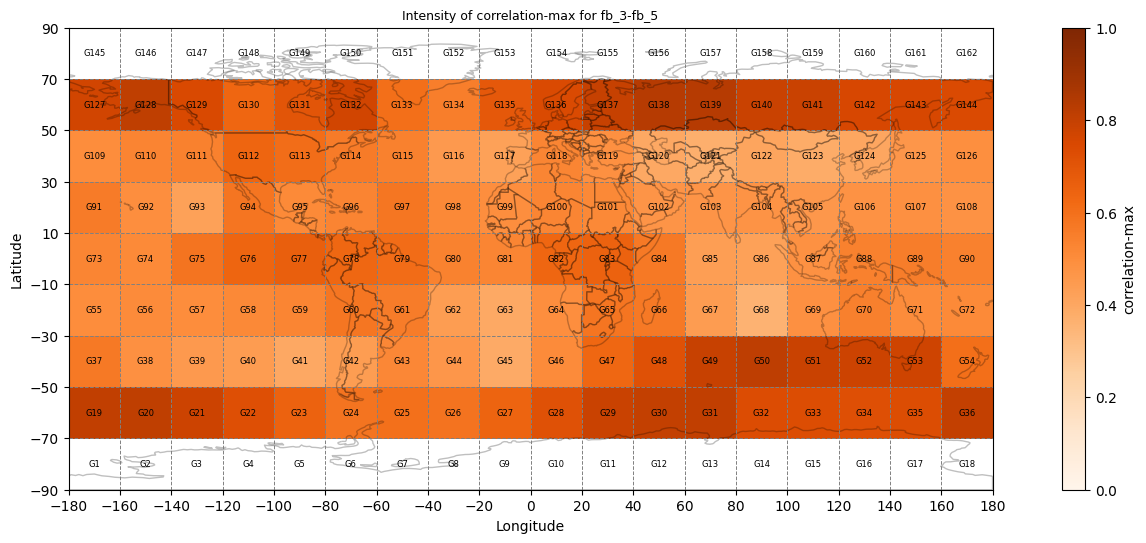

In [32]:



def plot_grid_with_intensity(grid, width, depth, all_data, intensity_column):
    fig, ax = plt.subplots(figsize=(18, 6))
    cmap = 'Oranges'
    world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))
    world.plot(ax=ax, facecolor='none', edgecolor='black', cmap=cmap, alpha=0.25, zorder=2)
    # world.plot(ax=ax,facecolor='none',edgecolor='k', alpha=0.25, zorder= 2)
    for lat in np.arange(-90, 91, depth):
        ax.axhline(y=lat, color='gray', linestyle='--', linewidth=0.7)

    # Plot longitude lines
    for lon in np.arange(0, 361, width):  # Adjusted range to match grid calculation
        ax.axvline(x=lon - 180, color='gray', linestyle='--', linewidth=0.7)
    # Calculate the intensity of q1 mean for each grid cell
    intensities = np.zeros(grid.shape)

    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            specific_key = grid[lat_idx, lon_idx]
            intensity = all_data.loc[specific_key, intensity_column] if specific_key in all_data.index else np.nan
            intensities[lat_idx, lon_idx] = intensity

  
    im = ax.imshow(intensities, cmap=cmap, extent=[-180, 180, -90, 90], origin='lower')
    # im.set_clim(vmin=0, vmax=1)
    # Add color bar
    cbar = plt.colorbar(im, ax=ax)
    im.set_clim(vmin=0, vmax=1)
    
    cbar.set_label(intensity_column)

    # Plot grid IDs
    for lon_idx in range(grid.shape[1]):
        for lat_idx in range(grid.shape[0]):
            lat_start = -90 + lat_idx * depth
            lon_start = lon_idx * width
            ax.text(lon_start + width / 2 - 180, lat_start + depth / 2, grid[lat_idx, lon_idx], ha='center', va='center', color='black', fontsize= 6)

    # Set x and y label frequency
    ax.set_xticks(np.arange(-180, 181, 20))
    ax.set_yticks(np.arange(-90, 91, 20))

    # Set title and labels
    ax.set_title(f'Intensity of {intensity_column} for {Band_Key}', fontsize =9)
    ax.set_xlabel('Longitude')
    ax.set_ylabel('Latitude')
    folder_path = r"C:\\PROJECT-DEMETER\\Anomaly\\GRID-Method\\GRID-FB-UP_ICE\\Heat_maps"

    os.makedirs(folder_path, exist_ok=True)

    plt.savefig(os.path.join(folder_path, f'{Band_Key}_{intensity_column}.png'))
    plt.show()


grid = create_grid(20, 20)

# Plot grid with intensity
plot_grid_with_intensity(grid, 20, 20, new_df, 'correlation-max')
